In [59]:
import pandas as pd
import numpy as np
import json
import gc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# Path configuration
BASE_PATH = "/content/drive/MyDrive/AmazonReviewsAnalysis"
DATA_PATH = f"{BASE_PATH}/data"
PLOTS_PATH = f"{BASE_PATH}/plots"
CSV_PATH = f"{BASE_PATH}/csv"

CATEGORIES = ["Appliances", "All_Beauty", "Handmade_Products", "Software", "Magazine_Subscriptions"]

def robust_load_jsonl(path):
    """robust loader to skip corrupted lines."""
    records = []
    try:
        # Try fast load first
        return pd.read_json(path, lines=True)
    except (ValueError, json.JSONDecodeError):
        print(f"  Standard parser failed for {path}, using line-by-line fallback...")
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    continue # Skip the corrupted lines
        return pd.DataFrame(records)


def plot_sleek_dashboard(df, cat, save_path):
    """Creates a 1x3 horizontal dashboard with slim bars"""
    # Use a clear style
    sns.set_theme(style="white")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    color_palette = "viridis"
    labels = ['Text Only', 'With Images']

    # 1. Overall Mean (All Data)
    sns.barplot(ax=axes[0], data=df, x='has_images', y='helpful_vote', hue='has_images',
                alpha=0.2, width=0.3, errorbar=None, palette=color_palette, legend=False)
    sns.pointplot(ax=axes[0], data=df, x='has_images', y='helpful_vote', hue='has_images',
                  palette=color_palette, markers="D", markersize=7, capsize=.1,
                  linestyle='none', legend=False)
    axes[0].set_title("Overall Avg. Engagement", fontsize=12, fontweight='bold', pad=15)

    # 2. Conditional Mean (Active Reviews only: Votes > 0)
    df_active = df[df['helpful_vote'] > 0]
    if not df_active.empty:
        sns.barplot(ax=axes[1], data=df_active, x='has_images', y='helpful_vote', hue='has_images',
                    alpha=0.2, width=0.3, errorbar=None, palette=color_palette, legend=False)
        sns.pointplot(ax=axes[1], data=df_active, x='has_images', y='helpful_vote', hue='has_images',
                      palette=color_palette, markers="D", markersize=7, capsize=.1,
                      linestyle='none', legend=False)
    axes[1].set_title("Depth of Engagement (Votes > 0)", fontsize=12, fontweight='bold', pad=15)

    # 3. Conversion Rate (%)
    conv_df = df.groupby('has_images')['helpful_any'].mean().reset_index()
    conv_df['helpful_any'] *= 100
    sns.barplot(ax=axes[2], data=conv_df, x='has_images', y='helpful_any', hue='has_images',
                alpha=0.2, width=0.3, palette=color_palette, legend=False)
    sns.pointplot(ax=axes[2], data=conv_df, x='has_images', y='helpful_any', hue='has_images',
                  palette=color_palette, markers="D", markersize=7, linestyle='none', legend=False)
    axes[2].set_title("Conversion Rate (%)", fontsize=12, fontweight='bold', pad=15)
    axes[2].set_ylabel("Reviews with ≥ 1 Vote (%)")

    # Global Formatting
    for ax in axes:
        ax.set_xticks([0, 1])
        ax.set_xticklabels(labels)
        ax.set_xlabel('')
        sns.despine(ax=ax, left=True)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.suptitle(f"Impact Analysis: {cat}", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout() # "Autosize" feature
    plt.savefig(save_path, bbox_inches='tight', dpi=600)
    plt.show()
    plt.close()


Mounted at /content/drive



Processing: Appliances ====================


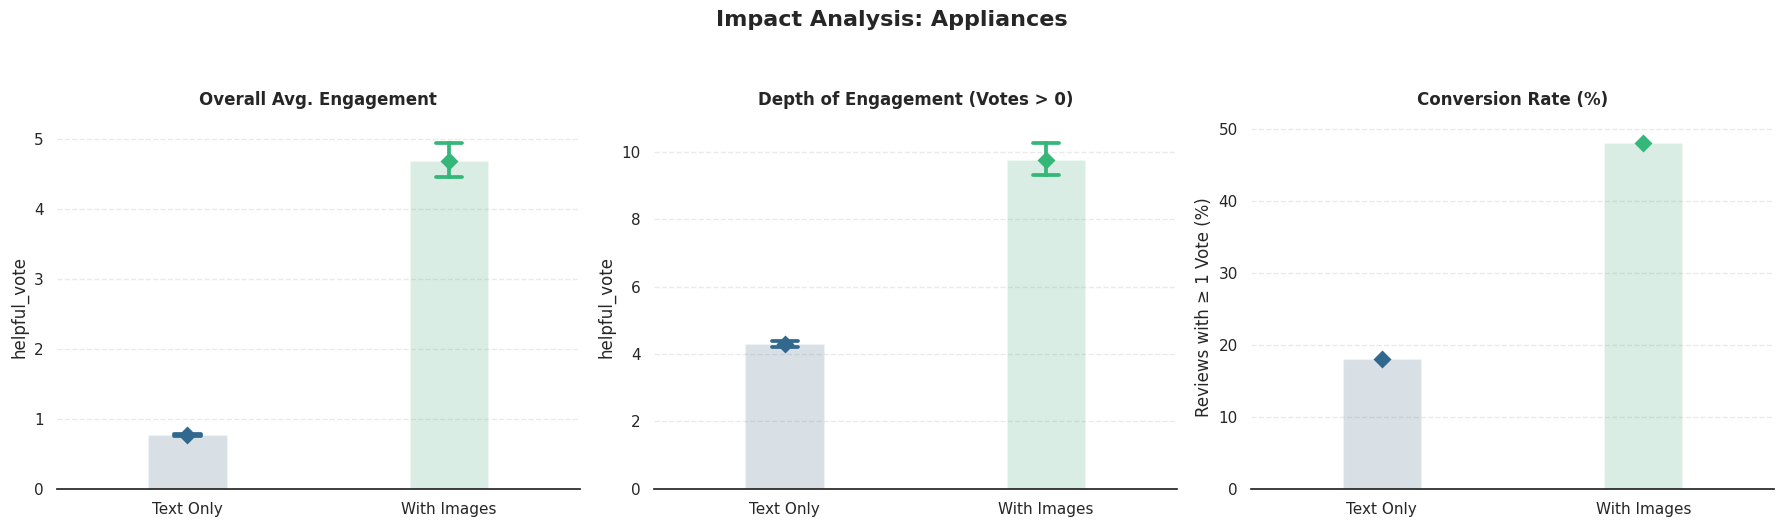


Processing: All_Beauty ====================


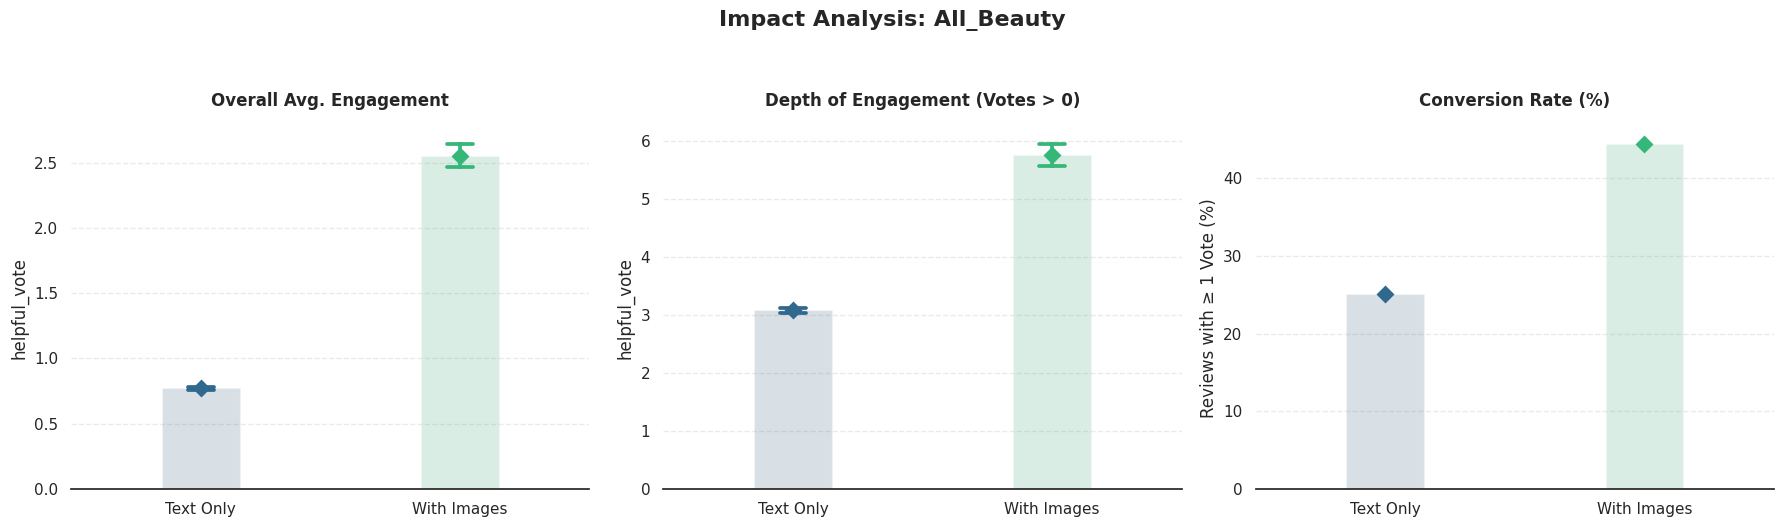


Processing: Handmade_Products ====================


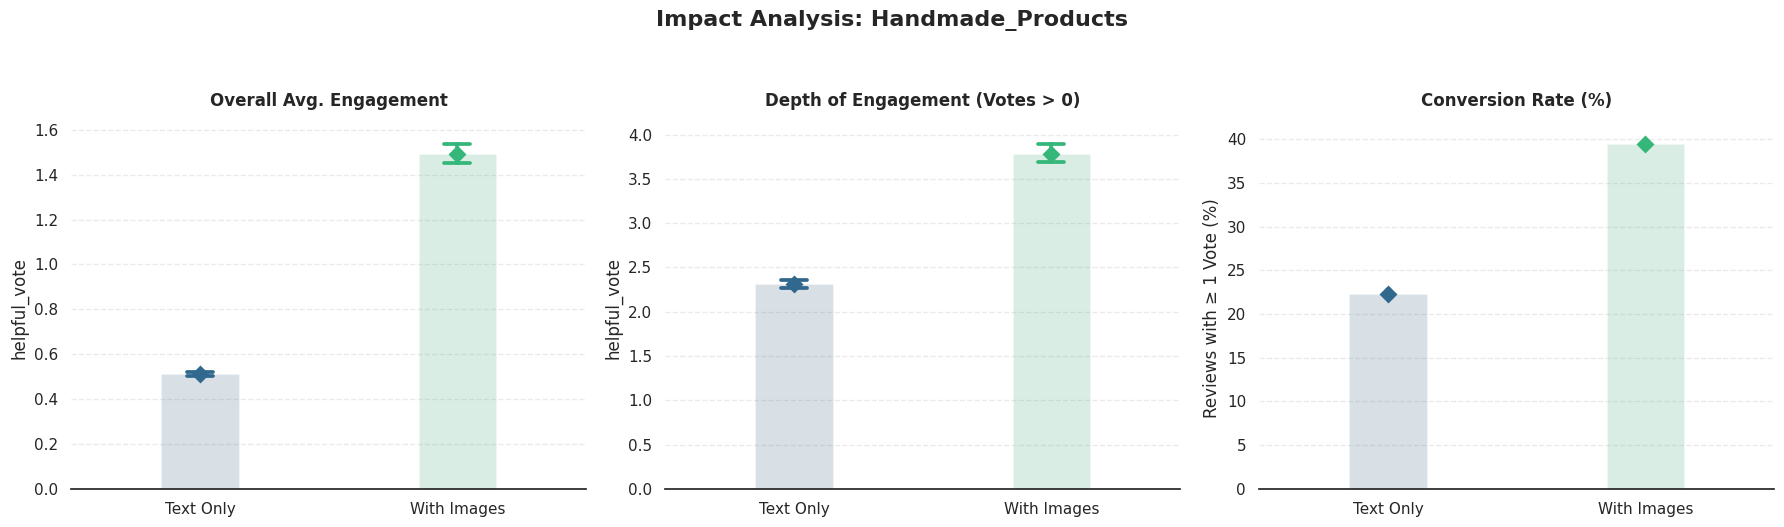


Processing: Software ====================


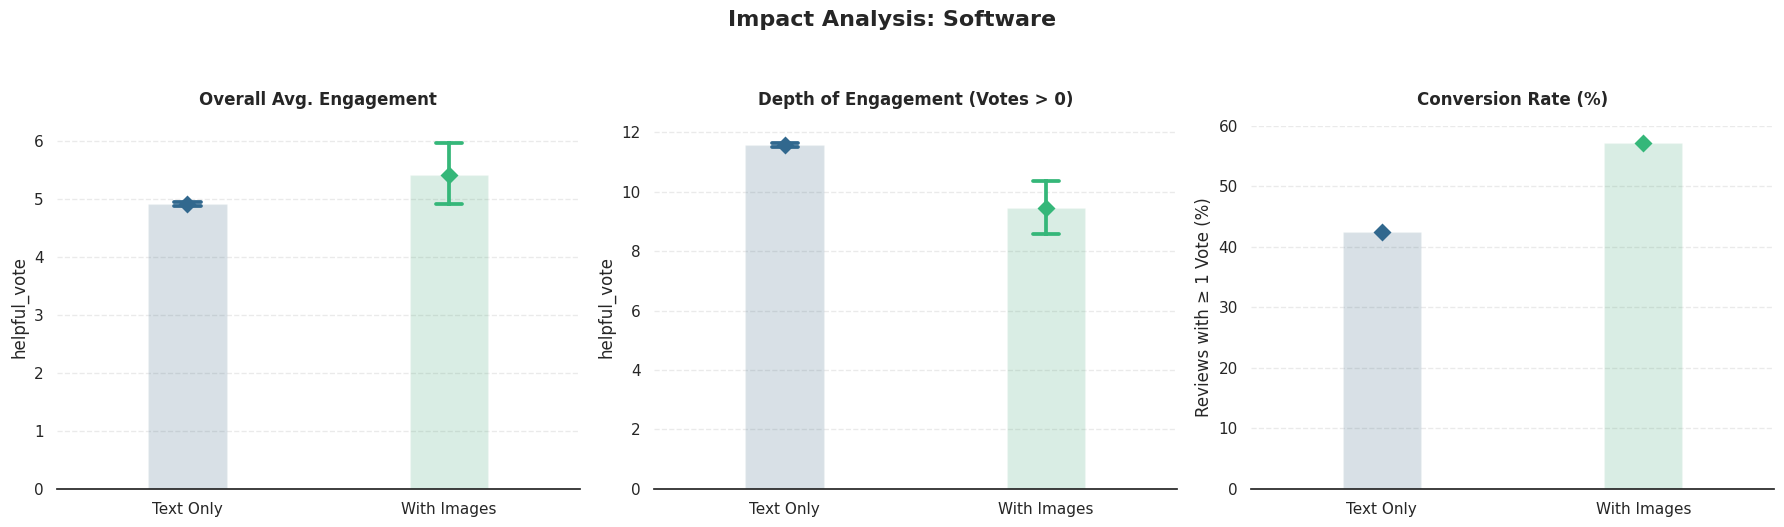


Processing: Magazine_Subscriptions ====================
  Standard parser failed for /content/drive/MyDrive/AmazonReviewsAnalysis/data/Magazine_Subscriptions.jsonl, using line-by-line fallback...


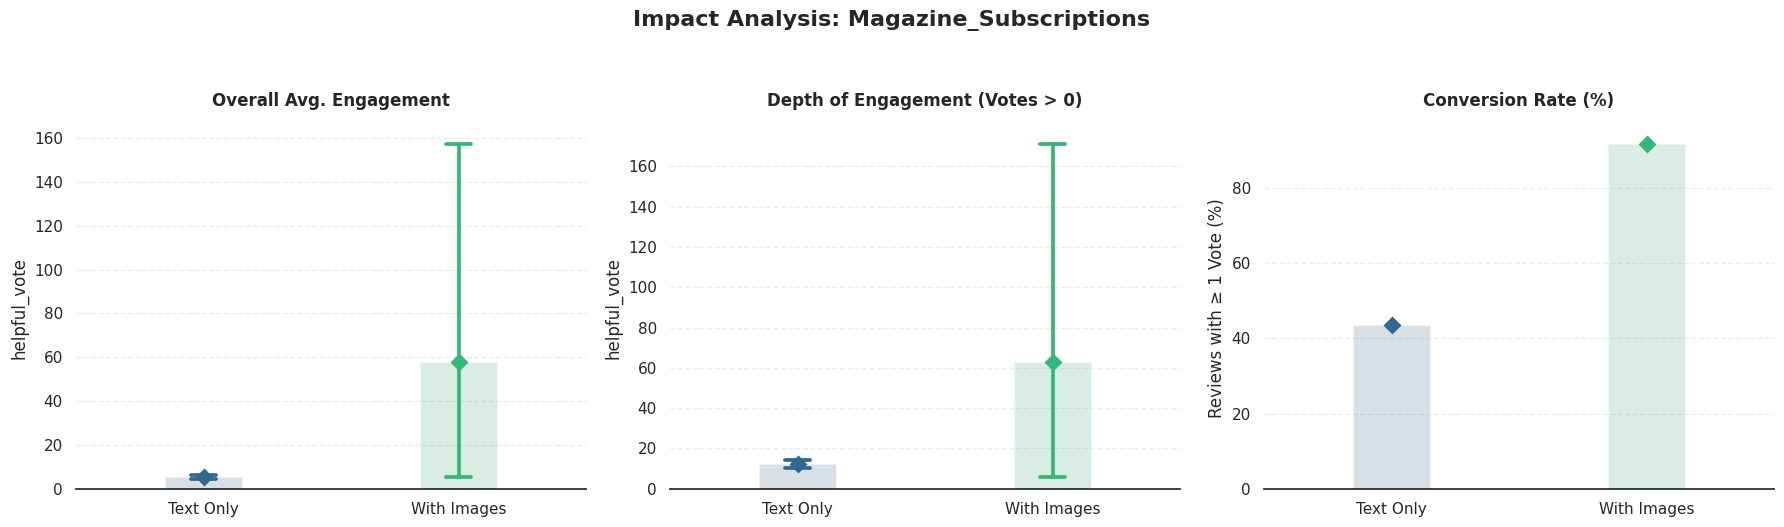


FINAL SUMMARY OF IMAGE IMPACT


,Category,Correlation,P_Value,Conv_Text,Conv_Img,Mean_Text,Mean_Img,Cond_Mean_Img
0,Appliances,0.0613,0.00e+00,18.0%,48.1%,0.77,4.70,9.76
1,All_Beauty,0.0909,0.00e+00,25.1%,44.4%,0.77,2.55,5.75
2,Handmade_Products,0.0792,0.00e+00,22.2%,39.4%,0.51,1.49,3.79
3,Software,0.0006,2.18e-01,42.5%,57.2%,4.92,5.41,9.47
4,Magazine_Subscriptions,0.0879,1.04e-08,43.5%,91.7%,5.30,57.75,63.00



 Summary CSV exported to: /content/drive/MyDrive/AmazonReviewsAnalysis/csv/image_helpfulness_final_summary.csv


In [60]:
summary_results = []

for cat in CATEGORIES:
    print(f"\nProcessing: {cat} " + "="*20)
    review_path = f"{DATA_PATH}/{cat}.jsonl"

    # skip corrupted lines
    df = robust_load_jsonl(review_path)

    if df.empty or 'images' not in df.columns:
        print(f"  Skipping {cat}: No usable data.")
        continue

    # Feature Engineering
    df['has_images'] = df['images'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
    df['helpful_any'] = (df['helpful_vote'] > 0).astype(int)

    if df['has_images'].nunique() < 2:
        print(f"  Skipping {cat}: No variation in image presence (e.g., zero images in category).")
        continue

    # Statistical Computations
    corr, p_val = pointbiserialr(df['has_images'].astype(int), df['helpful_vote'])
    means = df.groupby('has_images')['helpful_vote'].mean()
    conv = df.groupby('has_images')['helpful_any'].mean() * 100

    df_active = df[df['helpful_vote'] > 0]
    cond_means = df_active.groupby('has_images')['helpful_vote'].mean() if not df_active.empty else {True: 0, False: 0}

    # Populate summary with all key metrics
    summary_results.append({
        "Category": cat,
        "Correlation": round(corr, 4),
        "P_Value": f"{p_val:.2e}",
        "Conv_Text": f"{conv.get(False, 0):.1f}%",
        "Conv_Img": f"{conv.get(True, 0):.1f}%",
        "Mean_Text": round(means.get(False, 0), 2),
        "Mean_Img": round(means.get(True, 0), 2),
        "Cond_Mean_Img": round(cond_means.get(True, 0), 2)
    })

    # Plotting
    plot_sleek_dashboard(df, cat, f"{PLOTS_PATH}/{cat}_sleek_analysis.png")

    # Memory Cleanup
    del df, df_active
    gc.collect()

# --- Final Export and Display ---
summary_df = pd.DataFrame(summary_results)

print("\n" + "="*50)
print("FINAL SUMMARY OF IMAGE IMPACT")
print("="*50)
display(summary_df)

# Export the CSV to drive
summary_df.to_csv(f"{CSV_PATH}/image_helpfulness_final_summary.csv", index=False)
print(f"\n Summary CSV exported to: {CSV_PATH}/image_helpfulness_final_summary.csv")